<a href="https://colab.research.google.com/github/CuicuiZhang01/Cuicui__INFO5731_Spring2026/blob/main/Zhang_Cuicui_Assignment_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



# **INFO5731 Assignment 2**

In this assignment, we will delve into various aspects of natural language processing (NLP) and text analysis. The tasks are designed to deepen your understanding of key NLP concepts and techniques, as well as to provide hands-on experience with practical applications.

Through these tasks, you'll gain practical experience in NLP techniques such as N-gram analysis, TF-IDF, word embedding model creation, and sentiment analysis dataset creation.

**Expectations**:
*   Use the provided .*ipynb* document to write your code & respond to the questions. Avoid generating a new file.
*   Write complete answers and run all the cells before submission.
*   Make sure the submission is "clean"; *i.e.*, no unnecessary code cells.
*   Once finished, allow shared rights from top right corner (*see Canvas for details*).


**Total points**: 100

**Deadline**: See Canvas

**Late Submission will have a penalty of 10% reduction for each day after the deadline.**


## Question 1 (25 points)

**Understand N-gram**

Write a python program to conduct N-gram analysis based on the dataset in your assignment two. You need to write codes from **scratch instead of using any pre-existing libraries** to do so:

(1) Count the frequency of all the N-grams (N=3) and (N=2).

(2) Calculate the probabilities for all the bigrams in the dataset by using the formula  count(w2 w1) / count(w2). For example, count(really like) / count(really) = 1 / 3 = 0.33.
w
(3) Extract all the noun phrases and calculate the relative
probabilities of each review in terms of other reviews (abstracts, or tweets) by using the formula  frequency (noun phrase) / max frequency (noun phrase) on the whole dataset.

Print out the result in a table with column name the all the noun phrases and row name as all the 100 reviews (abstracts, or tweets).

In [ ]:
import pandas as pd
import re

# Read the dataset
df = pd.read_csv("ml_ai_tweets_cleaned.csv")

# Function to clean tweet text
def clean_text(text):

    text = text.lower()

    text = re.sub(r'http\S+', '', text)   # remove URLs

    text = re.sub(r'@\w+', '', text)      # remove @mentions

    text = re.sub(r'#', '', text)         # remove hashtag symbol but keep the word

    text = re.sub(r"[^a-z0-9\s]", "", text)   # remove punctuation

    return text.strip()

# Apply cleaning function to text column
df["clean_text"] = df["text"].apply(clean_text)

df["clean_text"]

0     click here  to see how connectism explains why...
1     we arent just using ai were living through the...
2     alpha lives at the intersection of physics mat...
3     one classroom many learnerscan ai help reach t...
4     times of india  focus on job creation says jag...
                            ...                        
95    hegseth labels anthropic a supply chain threat...
96    for sale        9888 domains domainnames ai ar...
97    click here  music video to understand the dime...
98    scrapy revolutionizes web scraping how this op...
99    nobody about this how do we deal with al takin...
Name: clean_text, Length: 100, dtype: object

In [ ]:
# View first 5 rows
df.head()

,tweet_id,username,text,clean_text
0,2027962868503629922,SteveKlinko,click here: https://t.co/dqjpeski0v to see how...,click here to see how connectism explains why...
1,2027962826204320248,JiaMonroe,we aren't just using ai; we’re living through ...,we arent just using ai were living through the...
2,2027962498566308003,JiaMonroe,"alpha lives at the intersection of physics, ma...",alpha lives at the intersection of physics mat...
3,2027962255602864520,jcrelc_journal,"one classroom, many learners—can ai help reach...",one classroom many learnerscan ai help reach t...
4,2027961190530310444,nordicinst,times of india @timesofindia: focus on job cre...,times of india focus on job creation says jag...


In [ ]:
# Save the dataframe to a new CSV file
df.to_csv("tweets_cleaned_dataset.csv", index=False)

In [ ]:
import pandas as pd
df = pd.read_csv("tweets_cleaned_dataset.csv")

In [ ]:
# Task 1.1
from collections import Counter

# =========================
# Tokenize text
# =========================
def tokenize(text):
    # Simple whitespace tokenizer
    if not text:
        return []
    return text.split()

tokenized_docs = [tokenize(doc) for doc in df["clean_text"]]

# =========================
# Build n-grams
# =========================
def build_ngrams(tokens, n):
    # Create n-grams using a sliding window
    grams = []
    for i in range(len(tokens) - n + 1):
        gram = tuple(tokens[i:i+n])
        grams.append(gram)
    return grams

# =========================
# Count all bigrams and trigrams
# =========================
all_bigrams = []
all_trigrams = []

for tokens in tokenized_docs:
    all_bigrams.extend(build_ngrams(tokens, 2))
    all_trigrams.extend(build_ngrams(tokens, 3))

bigram_counts = Counter(all_bigrams)
trigram_counts = Counter(all_trigrams)

# Print bigram frequencies
print("=====Top 20 bigram frequencies =====")
for gram, freq in bigram_counts.most_common(20):
    print(gram, ":", freq)

=====Top 20 bigram frequencies =====
('ai', 'artificialintelligence') : 23
('click', 'here') : 5
('artificialintelligence', 'machinelearning') : 5
('the', 'future') : 5
('artificialintelligence', 'ainews') : 4
('ainews', 'tech') : 4
('ai', 'machinelearning') : 4
('artificialintelligence', 'ai') : 4
('artificialintelligence', 'innovation') : 4
('innovation', 'technology') : 4
('here', 'to') : 3
('the', 'one') : 3
('at', 'the') : 3
('ai', 'is') : 3
('deal', 'with') : 3
('ai', 'and') : 3
('shaping', 'the') : 3
('future', 'of') : 3
('machinelearning', 'artificialintelligence') : 3
('mind', 'consciousness') : 3


In [ ]:
# Print trigram frequencies
print("=====Top 20 trigram frequencies =====")
for gram, freq in trigram_counts.most_common(20):
    print(gram, ":", freq)

=====Top 20 trigram frequencies =====
('ai', 'artificialintelligence', 'ainews') : 4
('artificialintelligence', 'ainews', 'tech') : 4
('artificialintelligence', 'innovation', 'technology') : 4
('click', 'here', 'to') : 3
('shaping', 'the', 'future') : 3
('the', 'future', 'of') : 3
('mind', 'consciousness', 'philosophy') : 3
('some', 'people', 'are') : 3
('artificialintelligence', 'knowledge', 'ai') : 2
('knowledge', 'ai', 'philosophy') : 2
('ai', 'philosophy', 'mind') : 2
('philosophy', 'mind', 'machinelearning') : 2
('mind', 'machinelearning', 'engineering') : 2
('times', 'of', 'india') : 2
('us', 'ai', 'artificialintelligence') : 2
('sold', 'for', '1b') : 2
('for', '1b', 'it') : 2
('on', 'amazon', 'kdp') : 2
('here', 'to', 'learn') : 2
('humanoid', 'summit', 'artificialintelligence') : 2


In [ ]:
# Task 1.2
# =========================
# Calculate bigram probabilities
# =========================
all_unigrams = []
for tokens in tokenized_docs:
    all_unigrams.extend(tokens)

unigram_counts = Counter(all_unigrams)

bigram_probabilities = {}

for (w2, w1), count in bigram_counts.items():
        bigram_probabilities[(w2, w1)] = count / unigram_counts[w2]

print("\n=====T0P 20 BIGRAM PROBABILITIES =====")
for gram, prob in list(bigram_probabilities.items())[:20]:
    print(gram, ":", round(prob, 4))


=====T0P 20 BIGRAM PROBABILITIES =====
('click', 'here') : 1.0
('here', 'to') : 0.375
('to', 'see') : 0.0263
('see', 'how') : 1.0
('how', 'connectism') : 0.1
('connectism', 'explains') : 0.5
('explains', 'why') : 1.0
('why', 'split') : 0.125
('split', 'brain') : 1.0
('brain', 'patients') : 1.0
('patients', 'still') : 1.0
('still', 'seem') : 0.25
('seem', 'like') : 1.0
('like', 'one') : 0.5
('one', 'person') : 0.2
('person', 'artificialintelligence') : 1.0
('artificialintelligence', 'knowledge') : 0.0253
('knowledge', 'ai') : 0.6667
('ai', 'philosophy') : 0.0204
('philosophy', 'mind') : 0.4


In [ ]:
# Task 1.3
# =========================
# Rule-based noun phrase extraction
# Pattern idea: (0 or more adjectives) + 1 or more noun-like words
# =========================

# Words that often are not useful as noun phrase heads
stopwords = {
    "is", "am", "are", "was", "were", "be", "been", "being",
    "do", "does", "did", "doing",
    "have", "has", "had",
    "and", "or", "but", "if", "because", "as", "while",
    "of", "at", "by", "for", "with", "about", "against",
    "between", "into", "through", "during", "before", "after",
    "above", "below", "to", "from", "up", "down", "in", "out",
    "on", "off", "over", "under", "again", "further", "then",
    "once", "here", "there", "when", "where", "why", "how",
    "all", "any", "both", "each", "few", "more", "most", "other",
    "some", "such", "no", "nor", "not", "only", "own", "same",
    "so", "than", "too", "very", "can", "will", "just", "should",
    "i", "you", "he", "she", "it", "we", "they",
    "me", "him", "them", "us",
    "what", "which", "who", "whom"
}

# Some adjective-like endings
adjective_suffixes = (
    "al", "ive", "ous", "ful", "less", "able", "ible", "ic", "ary", "ory"
)

# Some noun-like endings
noun_suffixes = (
    "tion", "sion", "ment", "ness", "ity", "ism", "age", "ship",
    "er", "or", "ist", "ence", "ance", "ing"
)

def is_adjective_like(word):
    # check common adjective endings
    return word.endswith(adjective_suffixes)

def is_noun_like(word):
    if word in stopwords:
        return False
    if not re.match(r'^[a-z0-9]+$', word):
        return False
    if word.endswith(noun_suffixes):
        return True
    if len(word) > 2:
        return True
    return False

def extract_noun_phrases(tokens):
    # A simple rule-based noun phrase extractor
    noun_phrases = []
    i = 0

    while i < len(tokens):
        phrase = []

        # Zero or more adjective-like words
        while i < len(tokens) and is_adjective_like(tokens[i]):
            phrase.append(tokens[i])
            i += 1

        # One or more noun-like words
        noun_count = 0
        while i < len(tokens) and is_noun_like(tokens[i]):
            phrase.append(tokens[i])
            noun_count += 1
            i += 1

        # Keep the phrase only if it has at least one noun-like word
        if noun_count > 0 and noun_count <= 3:
            noun_phrase = " ".join(phrase).strip()
            # skip hashtag phrases
            if noun_phrase.startswith("#"):
                continue

            if noun_phrase:
                noun_phrases.append(noun_phrase)
        else:
            # Move forward if no valid NP found
            i += 1

    return noun_phrases

# Extract noun phrases for each document
document_noun_phrases = []
for tokens in tokenized_docs:
    phrases = extract_noun_phrases(tokens)
    document_noun_phrases.append(phrases)

# =========================
# Count noun phrase frequency on the whole dataset
# =========================
all_noun_phrases = []
for phrases in document_noun_phrases:
    all_noun_phrases.extend(phrases)

noun_phrase_counts = Counter(all_noun_phrases)

print("\n=====TOP 20 NOUN PHRASE FREQUENCIES =====")
for phrase, freq in noun_phrase_counts.most_common(20):
    print(phrase, ":", freq)


=====TOP 20 NOUN PHRASE FREQUENCIES =====
click : 5
artificialintelligence : 5
artificialintelligence ainews tech : 4
the : 4
learn : 3
people : 3
using : 2
building : 2
data centres : 2
machinelearning : 2
love : 2
youre building : 2
artificialintelligence machinelearning : 2
robotics machinelearning artificialintelligence : 2
predicted : 2
news : 2
artificialintelligence artprice businessinsights : 2
music video : 2
artificialintelligence engineering : 2
musk launched : 2


In [ ]:
# =========================
# Build the relative probability table
# =========================

# List of all noun phrases in the dataset
all_phrase_columns = sorted(noun_phrase_counts.keys())

# Create result table with float values
result_table = pd.DataFrame(
    0.0,
    index=range(len(df["clean_text"])),
    columns=all_phrase_columns
)

# Fill table row by row
for doc_index, phrases in enumerate(document_noun_phrases):
    doc_phrase_counts = Counter(phrases)

    for phrase, freq in doc_phrase_counts.items():
        max_freq_in_dataset = noun_phrase_counts[phrase]
        result_table.loc[doc_index, phrase] = freq / max_freq_in_dataset

# Use document text as row labels if needed
result_table.index = [f"tweet_{i+1}" for i in range(len(df["clean_text"]))]

# Round for better display
result_table = result_table.round(3)
result_table

,200line python implementation,2026,abby the last,accreditation services,acquisition serious inquiries,action,agencies,agent milvus blog,agents,agents actually thinking,...,viralvideos reelsvideo,want,way,women artificialintelligence machinelearning,wonder,work launches,work learn,would betray everyone,years the builders,youre building
tweet_1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
tweet_2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
tweet_3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
tweet_4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
tweet_5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
tweet_96,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
tweet_97,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
tweet_98,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
tweet_99,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Question 2 (25 points)

**Undersand TF-IDF and Document representation**

Starting from the documents (all the reviews, or abstracts, or tweets) collected for assignment two, write a python program:

(1) To build the documents-terms weights (tf * idf) matrix.

(2) To rank the documents with respect to query (design a query by yourself, for example, "An Outstanding movie with a haunting performance and best character development") by using cosine similarity.

Note: You need to write codes from scratch instead of using any **pre-existing libraries** to do so.

In [ ]:
# Task 2.1
import pandas as pd
import math
from collections import Counter

# =========================
# Build vocabulary
# =========================
vocabulary = set()
for tokens in tokenized_docs:
    vocabulary.update(tokens)
vocabulary = sorted(list(vocabulary))

# =========================
# Compute Term Frequency (TF)
# =========================
tf_matrix = []
for tokens in tokenized_docs:
    word_count = Counter(tokens)
    total_words = len(tokens)
    tf_row = {}
    for word in vocabulary:
        tf_row[word] = word_count[word] / total_words if total_words > 0 else 0
    tf_matrix.append(tf_row)

# =========================
# Compute Document Frequency (DF)
# =========================
df_counts = {}
for word in vocabulary:
    count = 0
    for tokens in tokenized_docs:
        if word in tokens:
            count += 1
    df_counts[word] = count

# =========================
# Compute Inverse Document Frequency (IDF)
# =========================
N = len(tokenized_docs)
idf = {}
for word in vocabulary:
    idf[word] = math.log(N / (1 + df_counts[word]))

# =========================
# Compute TF-IDF Matrix
# =========================
tfidf_matrix = []
for tf_row in tf_matrix:
    tfidf_row = {}
    for word in vocabulary:
        tfidf_row[word] = tf_row[word] * idf[word]
    tfidf_matrix.append(tfidf_row)

# Convert TF-IDF matrix to DataFrame
tfidf_df = pd.DataFrame(tfidf_matrix)
print("\n===== TF-IDF Document-Term Matrix =====")
tfidf_df


===== TF-IDF Document-Term Matrix =====


,10000,100daysofcode,100x,110,1b,1st,1x,2,20000,200line,...,xgboosts,years,yesterdays,york,you,younis,your,youre,youtube,zhejiangs
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.076814,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
96,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
97,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
98,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0


In [ ]:
# Task 2.2
# =========================
# Create Query
# =========================
query = "ai machine learning technology future"

# Clean query
query = clean_text(query)
query_tokens = tokenize(query)

# =========================
# Compute Query TF-IDF
# =========================
query_counts = Counter(query_tokens)
query_len = len(query_tokens)

query_tf = {}

for word in vocabulary:
    query_tf[word] = query_counts[word] / query_len if query_len > 0 else 0

query_tfidf = {}

for word in vocabulary:
    query_tfidf[word] = query_tf[word] * idf[word]

# =========================
# Cosine Similarity
# =========================
def cosine_similarity(vec1, vec2):

    dot_product = 0
    norm1 = 0
    norm2 = 0

    for word in vocabulary:
        dot_product += vec1[word] * vec2[word]
        norm1 += vec1[word] ** 2
        norm2 += vec2[word] ** 2

    norm1 = math.sqrt(norm1)
    norm2 = math.sqrt(norm2)

    if norm1 == 0 or norm2 == 0:
        return 0

    return dot_product / (norm1 * norm2)

# =========================
# Rank Documents
# =========================
scores = []

for i, doc_vec in enumerate(tfidf_matrix):

    score = cosine_similarity(doc_vec, query_tfidf)

    scores.append((i, score))


# Sort documents by similarity score
scores.sort(key=lambda x: x[1], reverse=True)

print("===== Document Ranking Based on Cosine Similarity =====")

for doc_id, score in scores:
    print("Tweet", doc_id, "Similarity:", round(score, 4))

===== Document Ranking Based on Cosine Similarity =====
Tweet 62 Similarity: 0.1709
Tweet 31 Similarity: 0.1573
Tweet 52 Similarity: 0.1424
Tweet 82 Similarity: 0.133
Tweet 56 Similarity: 0.128
Tweet 34 Similarity: 0.1141
Tweet 86 Similarity: 0.1021
Tweet 70 Similarity: 0.0692
Tweet 53 Similarity: 0.0664
Tweet 71 Similarity: 0.0663
Tweet 90 Similarity: 0.0652
Tweet 50 Similarity: 0.061
Tweet 61 Similarity: 0.0578
Tweet 78 Similarity: 0.0503
Tweet 18 Similarity: 0.0484
Tweet 17 Similarity: 0.0426
Tweet 40 Similarity: 0.0024
Tweet 44 Similarity: 0.0023
Tweet 88 Similarity: 0.0021
Tweet 92 Similarity: 0.0021
Tweet 13 Similarity: 0.0021
Tweet 79 Similarity: 0.002
Tweet 1 Similarity: 0.0019
Tweet 10 Similarity: 0.0019
Tweet 63 Similarity: 0.0019
Tweet 19 Similarity: 0.0017
Tweet 85 Similarity: 0.0016
Tweet 83 Similarity: 0.0016
Tweet 69 Similarity: 0.0014
Tweet 15 Similarity: 0.0014
Tweet 23 Similarity: 0.0013
Tweet 37 Similarity: 0.0013
Tweet 84 Similarity: 0.0012
Tweet 9 Similarity: 0.001

## Question 3 (25 points)

**Create your own word embedding model**

Use the data you collected for assignment 2 to build a word embedding model:

(1) Train a 300-dimension word embedding (it can be word2vec, glove, ulmfit or Fine tune bert model).

(2) Visualize the embeddings using PCA or t-SNE in 2D. Create a scatter plot of at least 20 words and show how similar words cluster together.

(3) Calculate the cosine similarity between a few pairs of words to see if the model captures semantic similarity accurately.

Reference: https://machinelearningmastery.com/develop-word-embeddings-python-gensim/

Reference: https://jaketae.github.io/study/word2vec/

In [ ]:
# Task 3.1
import pandas as pd
import re
import matplotlib.pyplot as plt
from gensim.models import Word2Vec
from sklearn.decomposition import PCA
import numpy as np

# ============================
# Train Word2Vec embedding
# ============================

model = Word2Vec(
    sentences=tokenized_docs,
    vector_size=300,   # embedding dimension
    window=5,
    min_count=1,
    workers=4
)

print("Word embedding model trained.")

Word embedding model trained.


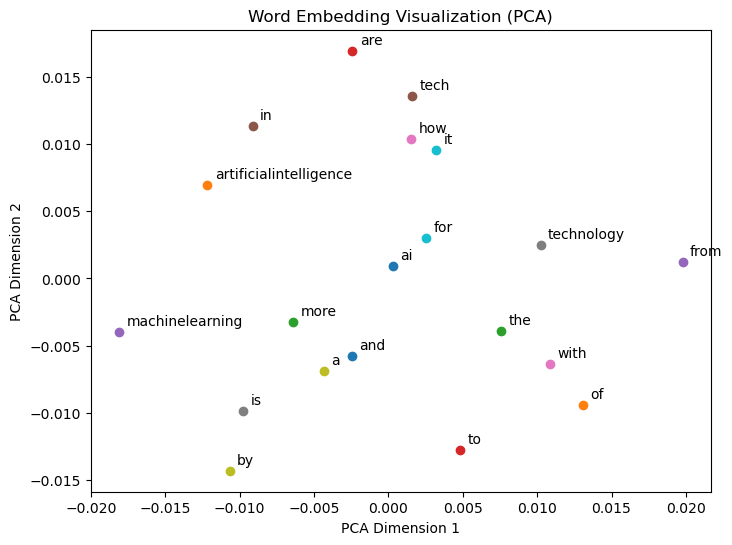

In [ ]:
# Task 3.2
# ============================
# Select words for visualization
# ============================

# Select at least 20 words from vocabulary
words = list(model.wv.index_to_key[:20])
word_vectors = [model.wv[word] for word in words]

# ============================
# Use PCA to reduce dimension
# ============================

pca = PCA(n_components=2)
reduced_vectors = pca.fit_transform(word_vectors)

# ============================
# Plot the embeddings
# ============================

plt.figure(figsize=(8,6))

for i, word in enumerate(words):

    x = reduced_vectors[i,0]
    y = reduced_vectors[i,1]

    plt.scatter(x, y)
    plt.text(x+0.0005, y+0.0005, word)

plt.title("Word Embedding Visualization (PCA)")
plt.xlabel("PCA Dimension 1")
plt.ylabel("PCA Dimension 2")

plt.show()

In [ ]:
# Task 3.3
# ============================
# Cosine similarity
# ============================

def cosine_similarity(v1, v2):

    dot = np.dot(v1, v2)
    norm1 = np.linalg.norm(v1)
    norm2 = np.linalg.norm(v2)

    return dot / (norm1 * norm2)

# Word pairs to test semantic similarity
pairs = [
    ("ai","machine"),
    ("ai","learning"),
    ("technology","data"),
    ("model","algorithm")
]
print("Cosine Similarity Between Word Pairs:\n")

for w1, w2 in pairs:

    if w1 in model.wv and w2 in model.wv:

        v1 = model.wv[w1]
        v2 = model.wv[w2]

        sim = cosine_similarity(v1, v2)

        print(f"{w1} - {w2}: {sim:.4f}")

    else:
        print(f"{w1} or {w2} not in vocabulary")

Cosine Similarity Between Word Pairs:

ai - machine: -0.0433
ai - learning: 0.0022
technology - data: 0.0918
model or algorithm not in vocabulary


## Question 4 (20 Points)

**Create your own training and evaluation dataset for an NLP task.**

 **You don't need to write program for this question!**

 For example, if you collected a movie review or a product review data, then you can do the following steps:

*   Read each review (abstract or tweet) you collected in detail, and annotate each review with a sentiment (positive, negative, or neutral).

*   Save the annotated dataset into a csv file with three columns (first column: document_id, clean_text, sentiment), upload the csv file to GitHub and submit the file link blew.

*   This datset will be used for assignment four: sentiment analysis and text classification.




1.   Which NLP Task you would like perform on your selected dataset
(NER, Summarization, Sentiment Analysis, Text classficication)
2.  Explain your labeling Schema you have used and mention those labels

3.  You can take AI assistance for labeling the data only.



#### Task 4.1
For this tweet dataset, I would like perform sentiment analysis.

#### Task 4.2
Each tweet in the dataset was labeled with one of three sentiment labels: positive, negative, or neutral. Positive indicates favorable opinions, negative indicates criticism or concerns, and neutral indicates factual or descriptive content without clear sentiment. AI assistance was used to help assign sentiment labels.

# The GitHub link of your final csv file


 Link: https://github.com/CuicuiZhang01/Cuicui__INFO5731_Spring2026/blob/main/tweet_100_annotated.csv



# Mandatory Question (5 Points)

Provide your thoughts on the assignment by filling this survey link. What did you find challenging, and what aspects did you enjoy? Your opinion on the provided time to complete the assignment.


This assignment helped me understand several NLP techniques such as N-grams, TF-IDF, and word embeddings. The most challenging part was implementing the algorithms from scratch without using existing libraries. Extracting noun phrases and calculating probabilities also required careful coding. I enjoyed working with real tweet data and seeing how NLP methods can analyze text. The time provided for the assignment was reasonable and sufficient to complete all tasks.